<a href="https://colab.research.google.com/github/borgesjose/Fundamentals-of-Quantum-Computing/blob/main/UA_1_e_UA_2_Hands_On.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Circuitos Quanticos de dois Qubits

Nesta atividade, são implementados os códigos dos circuitos quânticos de um e dois qubits em Python, utilizando o ambiente Jupyter (colabob). Os conhecimentos desta atividade estão vinculados às Unidades de Aprendizagem (UA) 1 e 2.

## Configração de Setup

In [ ]:
!pip install qiskit qiskit-aer pylatexenc

In [68]:
# Imports principais
from qiskit import QuantumCircuit,QuantumRegister
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import DensityMatrix, partial_trace
# Simulador
from qiskit_aer import AerSimulator

# (Opcional) Melhor visualização inline
%matplotlib inline

import numpy as np

## Circuito A:

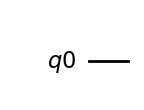

In [23]:
# Criando um circuito com 1 qubit no estado |0>
qReg = QuantumRegister(1, 'q0')
qc = QuantumCircuit(qReg)
qc.draw("mpl")

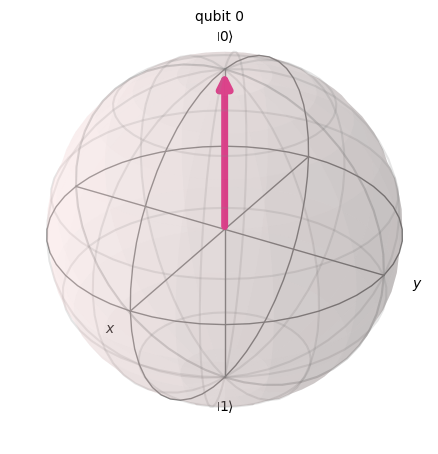

In [22]:
# Extrai o vetor de estado resultante do circuito atual e plota a esfea de bloch:
display(plot_bloch_multivector(Statevector.from_instruction(qc)))

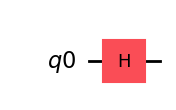

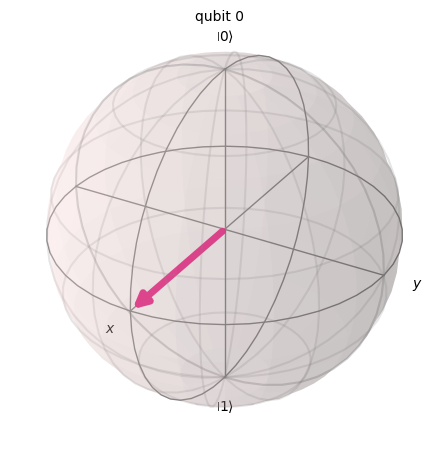

In [24]:
# Aplicando H para obter |1>
qc.h(0)                                # aplica H no qubit 0
display(qc.draw('mpl'))
display(plot_bloch_multivector(Statevector.from_instruction(qc)))

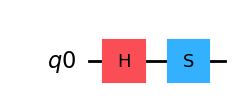

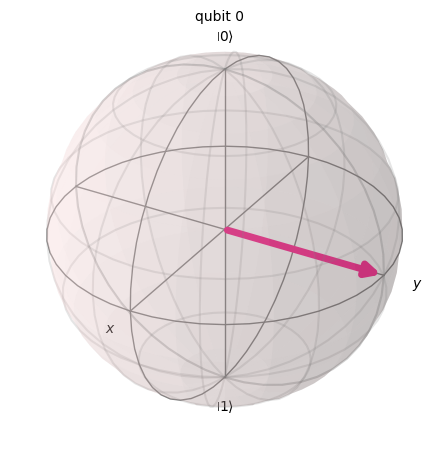

In [25]:
# Aplicando S para obter |1>
qc.s(0)                             # aplica S no qubit 0
display(qc.draw('mpl'))
display(plot_bloch_multivector(Statevector.from_instruction(qc)))

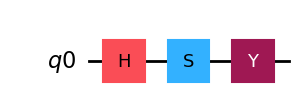

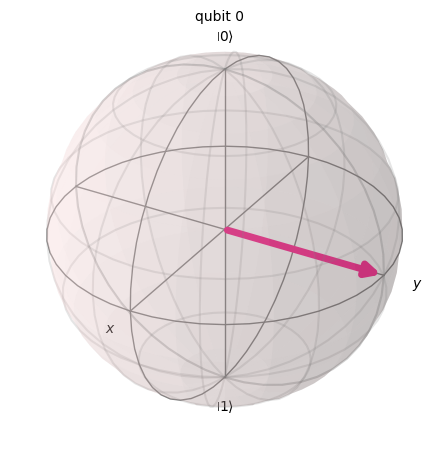

In [26]:
# Aplicando Y para obter |1>
qc.y(0)                             # aplica Y no qubit 0
display(qc.draw('mpl'))
display(plot_bloch_multivector(Statevector.from_instruction(qc)))

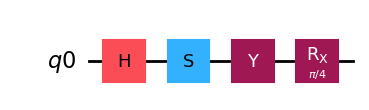

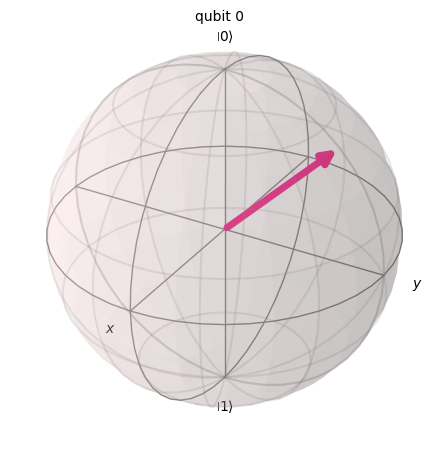

In [27]:
# Aplica a porta Rx com theta = pi/4
theta = np.pi / 4
qc.rx(theta, 0)
display(qc.draw('mpl'))
display(plot_bloch_multivector(Statevector.from_instruction(qc)))

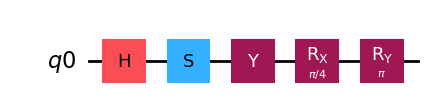

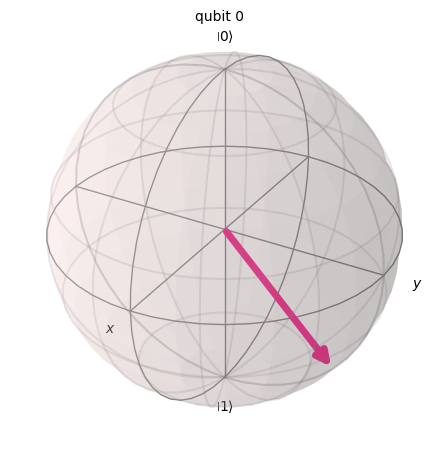

In [28]:
# Aplica a porta Ry com theta = pi
theta = np.pi
qc.ry(theta, 0)
display(qc.draw('mpl'))
display(plot_bloch_multivector(Statevector.from_instruction(qc)))

## Circuito B

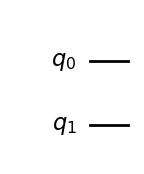

In [70]:
# Criando um circuito com 1 qubit no estado |0>
qReg = QuantumRegister(2, 'q')
qa = QuantumCircuit(qReg)
qa.draw("mpl")

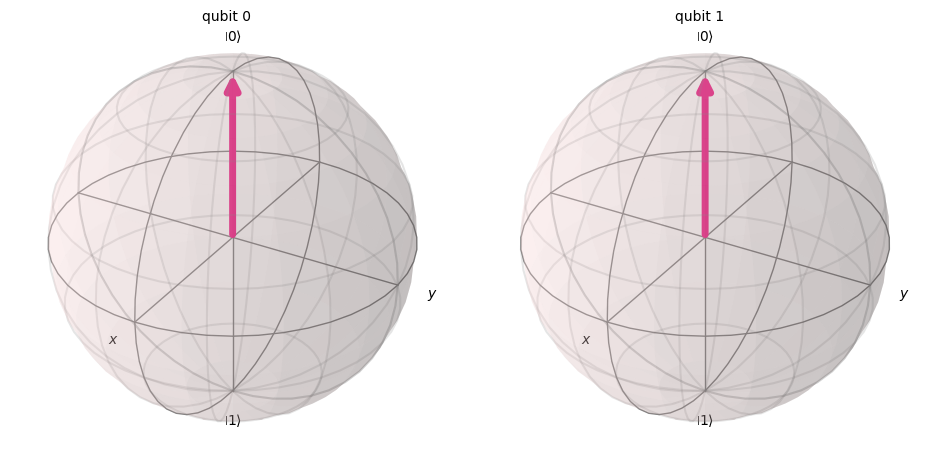

In [71]:
# Extrai o vetor de estado resultante do circuito atual e plota a esfea de bloch:
display(plot_bloch_multivector(Statevector.from_instruction(qa)))

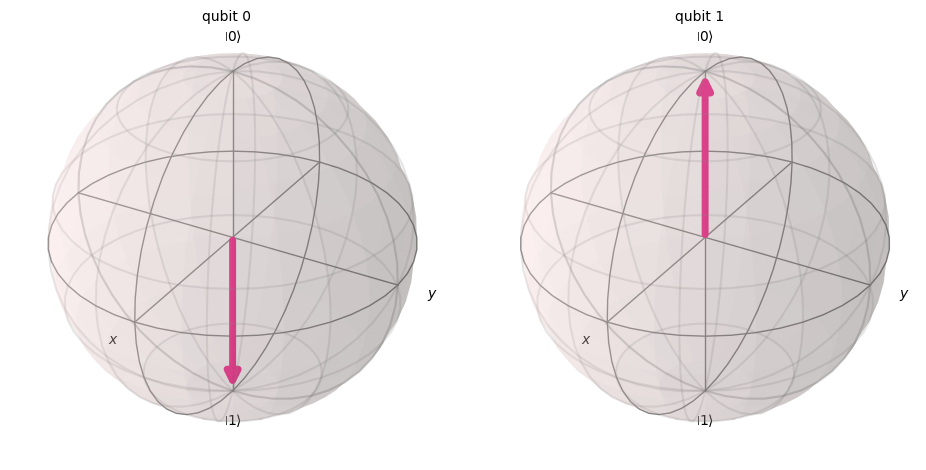

In [72]:
# Passo 1 – Porta X em q0  (NOT: |0⟩ → |1⟩)
qa.x(qReg[0]);
display(plot_bloch_multivector(Statevector.from_instruction(qa)))

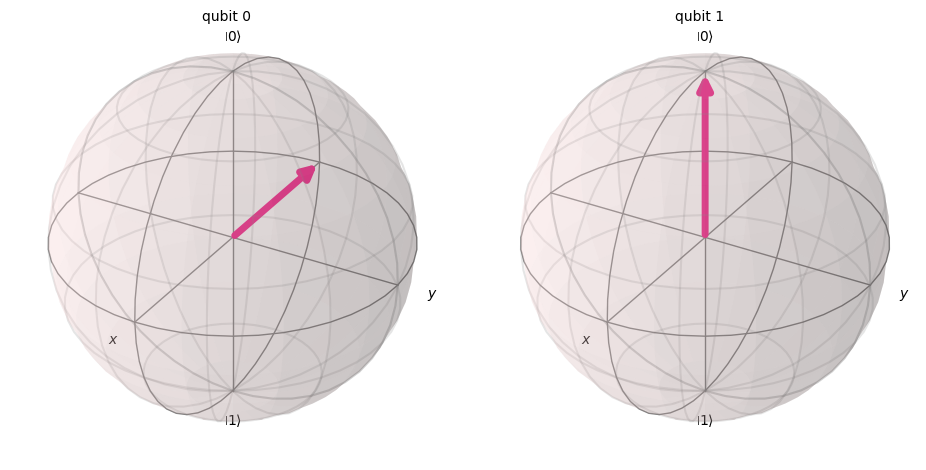

In [73]:
# Passo 2 – Porta H em q0  (Hadamard: cria superposição)
qa.h(qReg[0])
display(plot_bloch_multivector(Statevector.from_instruction(qa)))

In [74]:
# Passo 3 – Porta CNOT     (controle=q0, alvo=q1)
qa.cx(qReg[0], qReg[1]);

In [75]:
# Passo 4 – Porta H em q0  (segundo Hadamard: interferência)
qa.h(qReg[0]);

In [76]:
# Passo 5 – Porta Ry(π) em q1 (rotação de 180° em torno do eixo Y)
qa.ry(np.pi, qReg[1]);

=== Diagrama do Circuito B ===


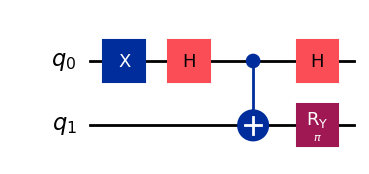

In [54]:
print("=== Diagrama do Circuito B ===")
qa.draw("mpl")

In [82]:
# Vetor de Bloch de cada qubit (deve ser ~[0, 0, 0])
bv_q0 = dm_q0.to_dict()
print("Matriz densidade q0:\n", dm_q0.data.round(3))
print("Matriz densidade q1:\n", dm_q1.data.round(3))

Matriz densidade q0:
 [[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]
Matriz densidade q1:
 [[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]


In [83]:
sv = Statevector(qa)
print(sv)

Statevector([ 0.5+0.j, -0.5+0.j,  0.5+0.j,  0.5+0.j],
            dims=(2, 2))


In [80]:
print("\n=== Probabilidades de cada estado ===")
probs = sv.probabilities_dict()
for estado, prob in sorted(probs.items()):
    print(f"  |{estado}⟩ : {prob:.4f}  ({prob*100:.1f}%)")


=== Probabilidades de cada estado ===
  |00⟩ : 0.2500  (25.0%)
  |01⟩ : 0.2500  (25.0%)
  |10⟩ : 0.2500  (25.0%)
  |11⟩ : 0.2500  (25.0%)
